# Business Problem: Bank Marketing Response Prediction

## Business Problem

A Portuguese bank conducts direct marketing campaigns through **phone calls** to promote **term deposit products**. However, contacting every customer requires significant time and resources, while many customers may not be interested in the product.

The objective is to build a **response prediction model** that identifies customers who are more likely to subscribe to a term deposit **before contacting them**.

The model will learn patterns from historical marketing campaign data, where the outcome of each customer is already known (`yes`/`no`).

## Example Use Case

Suppose the bank has **10,000 customers** to contact for a new marketing campaign.

Instead of calling all 10,000 customers equally:

**10,000 Customers → Predictive Model → Probability of Response → Prioritized Customers → Marketing Calls**

For example, the model may identify a group of customers with a high predicted probability of subscribing. The marketing team can prioritize these customers for calls, helping to:

* Increase the **conversion/response rate**
* Reduce unnecessary **marketing effort and cost**
* Improve **campaign targeting**
* Allocate sales resources more efficiently

## Business Objective

Build a **binary classification model** to predict whether a customer will subscribe to a bank term deposit.

### Target Variable

`y`

* `yes` → Customer subscribed to a term deposit
* `no` → Customer did not subscribe to a term deposit


## Overall Problem Statement

> **Predict which customers are most likely to subscribe to a term deposit so that the bank can target its marketing efforts toward higher-potential customers while reducing unnecessary contact costs.**


### Import Packages

In [2]:
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE, SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
#from sklearn.linear_model import LinearRegression, LogisticRegression
#from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz, export_text
#from sklearn.ensemble import BaggingClassifier, BaggingRegressor, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor
#from xgboost import XGBClassifier, XGBRegressor 
#from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
#from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB


### Load the Dataset

In [3]:
data = pd.read_csv('bank-additional.csv', sep= ';')

In [4]:
data.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no


### Exploratory Data Analysis

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [6]:
data.describe(include = 'all', percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,unique,top,freq,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,24.0,26.0,28.8,32.0,38.0,47.0,55.0,58.0,68.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# target column is imbalanced 
# data have feature naming issue as preesnce of '.' that violates INC rules
# data has presence of some ouliers

In [8]:
# to check the distribution of values
for col in data.columns:
    print('\n', (data[col].value_counts()/data.shape[0])*100, ', Data type of',col,data[col].dtype)


 age
32    5.243991
31    4.637048
30    4.297160
34    4.224326
35    4.175771
        ...   
69    0.048555
70    0.048555
85    0.024278
88    0.024278
19    0.024278
Name: count, Length: 67, dtype: float64 , Data type of age int64

 job
admin.           24.569070
blue-collar      21.461520
technician       16.775916
services          9.541151
management        7.865987
retired           4.030104
self-employed     3.860160
entrepreneur      3.593105
unemployed        2.694829
housemaid         2.670551
student           1.990774
unknown           0.946832
Name: count, dtype: float64 , Data type of job object

 marital
married     60.912843
single      27.992231
divorced    10.827871
unknown      0.267055
Name: count, dtype: float64 , Data type of marital object

 education
university.degree      30.687060
high.school            22.359796
basic.9y               13.935421
professional.course    12.988589
basic.4y               10.415149
basic.6y                5.535324
unknown       

In [9]:
df = data.copy()
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


### Renaming Features

In [10]:
df.columns = [col.strip().lower().replace('.','_') for col in df.columns]

In [11]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

### Handling duplicates

In [12]:
df.duplicated().sum()

0

### Missings handling: 

In [13]:
df.drop(columns = ['pdays'], inplace = True)

In [14]:
# find the columns which contains encoded missing values:  
value_to_find = ['unknown', 999, '?']
print('Columns that have encoded missings:',list(df.columns[df.isin(value_to_find).any()]))

Columns that have encoded missings: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'duration']


In [15]:
# udf to fill missings where values == [999, 'unknown']
def missings(x):
    if x.dtype == 'object':
        x[x == 'unknown'] = np.nan    # replace unknown with missing (np.nan)
        x = x.fillna(x.mode()[0])     # treat missing by mode imputation 
    else:
        x[x == 999] = np.nan          # replace 999 with missing (np.nan)
        x = x.fillna(x.median())      # treat missing by median imputation
    return x

In [16]:
df = df.apply(missings)

In [17]:
df.isna().sum().sum()

0

In [18]:
# to check the distribution of values
for col in df.columns:
    print('\n', (df[col].value_counts()/df.shape[0])*100, ', Data type of',col,df[col].dtype)


 age
32    5.243991
31    4.637048
30    4.297160
34    4.224326
35    4.175771
        ...   
69    0.048555
70    0.048555
85    0.024278
88    0.024278
19    0.024278
Name: count, Length: 67, dtype: float64 , Data type of age int64

 job
admin.           25.515902
blue-collar      21.461520
technician       16.775916
services          9.541151
management        7.865987
retired           4.030104
self-employed     3.860160
entrepreneur      3.593105
unemployed        2.694829
housemaid         2.670551
student           1.990774
Name: count, dtype: float64 , Data type of job object

 marital
married     61.179898
single      27.992231
divorced    10.827871
Name: count, dtype: float64 , Data type of marital object

 education
university.degree      34.741442
high.school            22.359796
basic.9y               13.935421
professional.course    12.988589
basic.4y               10.415149
basic.6y                5.535324
illiterate              0.024278
Name: count, dtype: float64 , 

In [19]:
# default has 99% no's so drop defaults 
df.drop(columns = ['default'], inplace = True)

# 99% values are similar (no variations) varience or CV is very close to zero so drop it 

### Outliers treatment:

In [20]:
# Handling Outliers
def outliers(x): 
    if x.dtype in (['int64', 'float64']):
         x = x.clip(lower = x.quantile(0.01)  , upper = x.quantile(0.99))    
    return x 

In [21]:
df = df.apply(outliers)

### Feature Encoding:
    To convert categorical features to numeric

In [22]:
# Label encoding for categorical features

binary_cols = ['loan', 'housing', 'y']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
# Ordinal Encoding for order based categorical features 

ordinal_cols = ['education', 'month']

ordinal_order = [
                  ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y','high.school', 'professional.course', 'university.degree'],  # education order
                  ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']  # month order  
]

oe = OrdinalEncoder(categories=ordinal_order).fit(df[ordinal_cols])
df[ordinal_cols] = oe.transform(df[ordinal_cols])
df.head(3)

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,30,blue-collar,married,3.0,1,0,cellular,4.0,fri,487.0,2,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0
1,39,services,single,4.0,0,0,telephone,4.0,fri,346.0,4,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
2,25,services,married,4.0,1,0,telephone,5.0,wed,227.0,1,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,0


In [24]:
# Nominal Encoding for converting categorical features to numeric

nominal_cols = ['job', 'marital', 'contact', 'day_of_week', 'poutcome']

ohe = OneHotEncoder(drop = 'first').fit(df[nominal_cols])
cat_encoded_ohe = ohe.transform(df[nominal_cols])    # Transform nominal columns to binary encoded features that gives a sparse matrix 
cat_encoded_ohe = pd.DataFrame(cat_encoded_ohe.toarray(), columns = ohe.get_feature_names_out())  # Convert sparse matrix to DataFrame, toarray() converts sparse matrix to normal NumPy array
cat_encoded_ohe

# ------------------------------------------OR--------------------------------------------------------

#  df = pd.get_dummies(df, columns= ['job', 'marital', 'contact', 'day_of_week', 'poutcome'], drop_first=True, dtype = 'float64')  # it makes changes at place
#  df.head()

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,contact_telephone,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [25]:
num_df = df[df.columns.difference(['job', 'marital', 'contact', 'day_of_week', 'poutcome'])]
final_df = pd.concat([num_df,cat_encoded_ohe], axis = 1)
final_df.head(3)

,age,campaign,cons_conf_idx,cons_price_idx,duration,education,emp_var_rate,euribor3m,housing,loan,...,job_unemployed,marital_married,marital_single,contact_telephone,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,2,-46.2,92.893,487.0,3.0,-1.8,1.313,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,39,4,-36.4,93.994,346.0,4.0,1.1,4.855,0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,25,1,-41.8,94.465,227.0,4.0,1.4,4.962,1,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [26]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   4119 non-null   int64  
 1   campaign              4119 non-null   int64  
 2   cons_conf_idx         4119 non-null   float64
 3   cons_price_idx        4119 non-null   float64
 4   duration              4119 non-null   float64
 5   education             4119 non-null   float64
 6   emp_var_rate          4119 non-null   float64
 7   euribor3m             4119 non-null   float64
 8   housing               4119 non-null   int32  
 9   loan                  4119 non-null   int32  
 10  month                 4119 non-null   float64
 11  nr_employed           4119 non-null   float64
 12  previous              4119 non-null   int64  
 13  y                     4119 non-null   int32  
 14  job_blue-collar       4119 non-null   float64
 15  job_entrepreneur     

In [27]:
Y = final_df['y']
X = final_df[final_df.columns.difference(['y'])]

### Feature Engineering

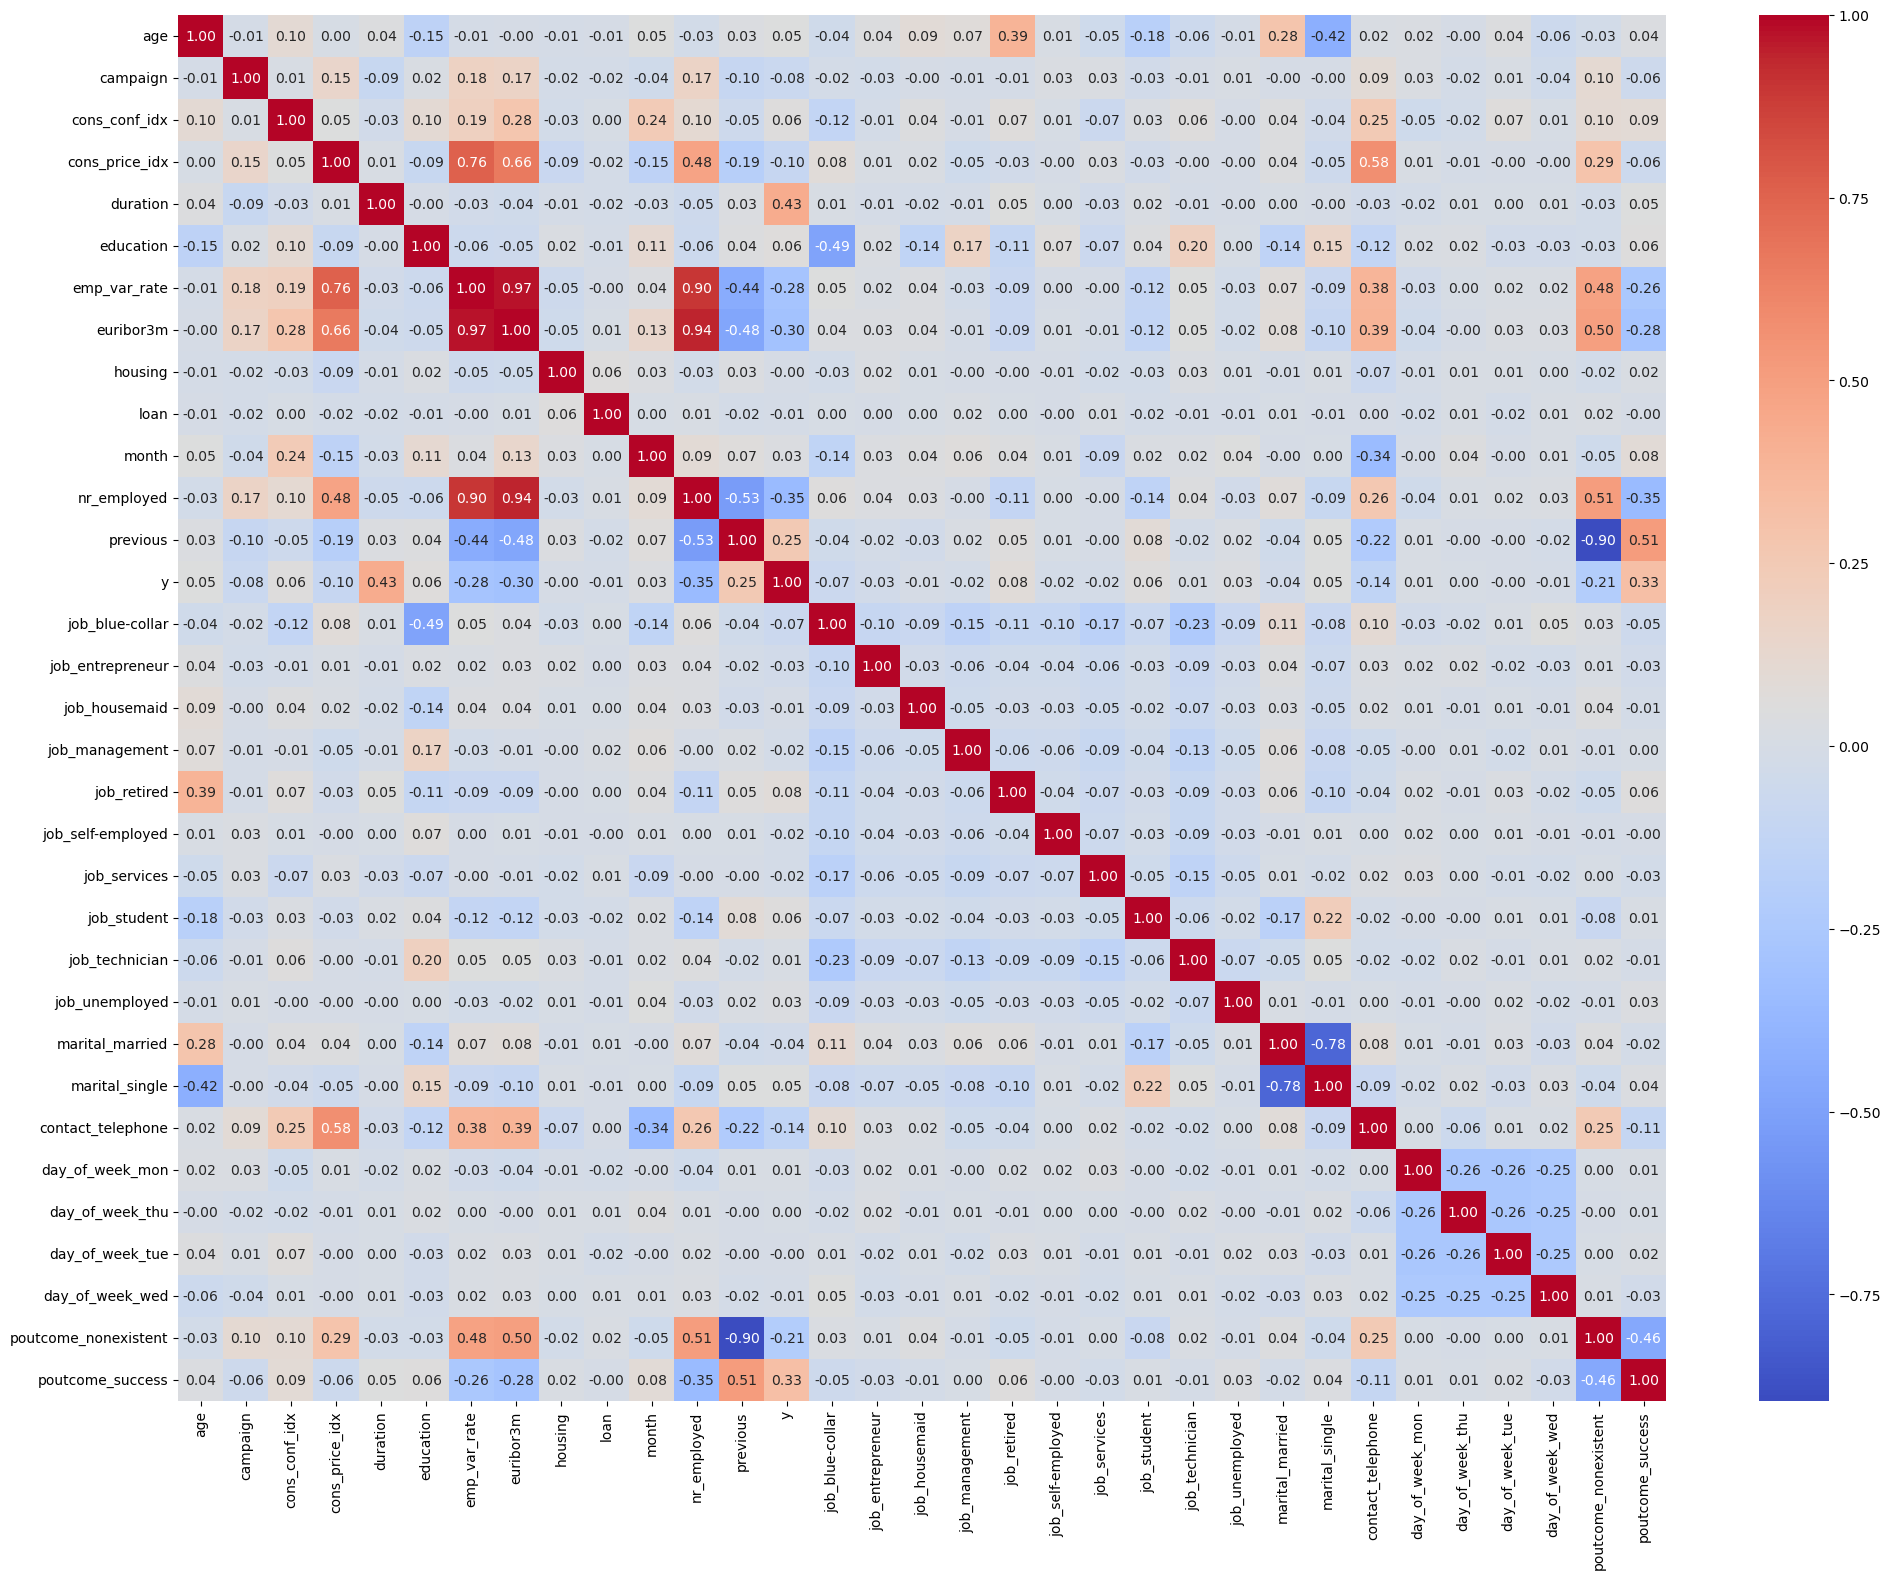

In [28]:
plt.figure(figsize=(24,18))
sns.heatmap(final_df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

In [29]:
# coffecient of varience
X.std()/X.mean()  
# Note: the feature that has cv very close to zero we have to drop that feature.

age                      0.249577
campaign                 0.897277
cons_conf_idx           -0.113213
cons_price_idx           0.006171
contact_telephone        1.344697
day_of_week_mon          1.954091
day_of_week_thu          1.946909
day_of_week_tue          1.974509
day_of_week_wed          2.045030
duration                 0.911503
education                0.389445
emp_var_rate            18.395624
euribor3m                0.478542
housing                  0.898206
job_blue-collar          1.913215
job_entrepreneur         5.180502
job_housemaid            6.037740
job_management           3.422836
job_retired              4.880475
job_self-employed        4.991163
job_services             3.079483
job_student              7.017383
job_technician           2.227584
job_unemployed           6.009732
loan                     2.279308
marital_married          0.796667
marital_single           1.604071
month                    0.362622
nr_employed              0.014259
poutcome_nonex

In [30]:
# RFE (feature elemination technique to select and eleminate feature based on the importance of feature, it drop feature feature based on least impact on accuracy)

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select= 17)
rfe = rfe.fit(X,Y)
print('selected_features:', X.columns[rfe.support_]) 
print('feature importance in all features:',rfe.ranking_)

selected_features: Index(['age', 'campaign', 'cons_conf_idx', 'cons_price_idx', 'day_of_week_mon',
       'day_of_week_thu', 'duration', 'education', 'emp_var_rate', 'euribor3m',
       'housing', 'job_technician', 'marital_married', 'month', 'nr_employed',
       'poutcome_success', 'previous'],
      dtype='object')
feature importance in all features: [ 1  1  1  1  5  1  1  3  6  1  1  1  1  1  7 15 16 11  9 14 10 12  1 13
  4  1  2  1  1  8  1  1]


In [33]:
from sklearn.feature_selection import RFECV

In [34]:
# SelectKBest (feature selection technique used to select top k features based on the statistical scores)

In [35]:
from sklearn.feature_selection import SelectKBest, f_classif   # for regression problem we use f_regression

In [36]:
skb = SelectKBest(score_func = f_classif, k = 17)   
X_new = skb.fit_transform(X, Y)
print('selected_features:', X.columns[skb.get_support()]) 


selected_features: Index(['age', 'campaign', 'cons_conf_idx', 'cons_price_idx',
       'contact_telephone', 'duration', 'education', 'emp_var_rate',
       'euribor3m', 'job_blue-collar', 'job_retired', 'job_student',
       'marital_single', 'nr_employed', 'poutcome_nonexistent',
       'poutcome_success', 'previous'],
      dtype='object')


In [37]:
# now we prefer to use the features that are selected by both RFE and SelectKBEst
X_new1 = X[list(set(list(X.columns[rfe.support_]) + list(X.columns[skb.get_support()])))]
X_new1.columns

Index(['poutcome_success', 'emp_var_rate', 'job_student', 'marital_single',
       'duration', 'housing', 'marital_married', 'job_blue-collar',
       'education', 'job_technician', 'month', 'cons_price_idx',
       'day_of_week_mon', 'previous', 'day_of_week_thu', 'campaign',
       'nr_employed', 'cons_conf_idx', 'age', 'job_retired', 'euribor3m',
       'poutcome_nonexistent', 'contact_telephone'],
      dtype='object')

In [38]:
# vif ( tells how a independent feature as correlated with other features by providinge vif_score( multicolineariy measur), high means shares the same information as other

x_final = X_new1[X_new1.columns.difference(['nr_employed','cons_price_idx','euribor3m','cons_conf_idx','poutcome_nonexistent','age','education'])]

vif_df = pd.DataFrame()
vif_df['features'] = x_final.columns
vif_df['vif_score'] = [variance_inflation_factor(x_final.values, i) for i in range(x_final.shape[1])]
vif_df = vif_df.sort_values(by='vif_score', ascending=False).reset_index(drop=True)
vif_df

,features,vif_score
0,month,5.933565
1,marital_married,4.881812
2,marital_single,2.783943
3,campaign,2.183042
4,housing,2.150187
5,duration,2.085997
6,contact_telephone,1.823181
7,previous,1.788716
8,emp_var_rate,1.473949
9,poutcome_success,1.417740


### Splitting data into Trian and Test

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x_final, Y, test_size = 0.3 ,stratify = Y, random_state = 42)

In [40]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2883, 16), (1236, 16), (2883,), (1236,))

### Logistic Regression

In [41]:
import statsmodels.formula.api as smf

In [42]:
x_train.columns = [col.strip().lower().replace('-','_') for col in x_train.columns]
x_test.columns = [col.strip().lower().replace('-','_') for col in x_test.columns]

In [43]:
train_df =  pd.concat([x_train,y_train],axis = 1)
test_df = pd.concat([x_test, y_test], axis = 1)

In [44]:
formula = y_train.name + ' ~ ' + (' + ').join(x_train.columns.difference(['month','contact_telephone','job_retired','day_of_week_thu','housing','marital_married','day_of_week_mon','campaign','job_blue_collar']))
formula

'y ~ duration + emp_var_rate + job_student + job_technician + marital_single + poutcome_success + previous'

In [45]:
lr_model = smf.logit(formula = formula, data = train_df ).fit()
print(lr_model.summary())

Optimization terminated successfully.
         Current function value: 0.208300
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 2883
Model:                          Logit   Df Residuals:                     2875
Method:                           MLE   Df Model:                            7
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.3974
Time:                        17:41:14   Log-Likelihood:                -600.53
converged:                       True   LL-Null:                       -996.64
Covariance Type:            nonrobust   LLR p-value:                8.849e-167
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -4.8177      0.191    -25.275      0.000      -5.191      -4.444
duration   

In [46]:
train_df['pred_prob'] = lr_model.predict(train_df)
test_df['pred_prob'] = lr_model.predict(test_df)

In [47]:
from sklearn.metrics import roc_auc_score

In [48]:
train_auc = roc_auc_score(train_df['y'], train_df['pred_prob'])
test_auc  = roc_auc_score(test_df['y'],  test_df['pred_prob'])

print("ROC AUC (Train):", train_auc)
print("ROC AUC (Test):", test_auc)

ROC AUC (Train): 0.926874941442752
ROC AUC (Test): 0.9079658223164127


In [49]:
train_gini = 2 * train_auc -1
test_gini = 2 * test_auc -1

print("Somers'D (Train):", train_gini)
print("Somers'D (Test):", test_gini)

Somers'D (Train): 0.8537498828855039
Somers'D (Test): 0.8159316446328253


In [50]:
cutoff = train_df['y'].mean()     # or we can also take ----> cutoff =  train_df['pred_prob'].mean(), because according to MLE: Mean of Actual Target ≈ Mean of Predicted Probability 
train_df['y_pred'] =  (train_df['pred_prob']>= cutoff).astype('int')
test_df['y_pred'] =  (test_df['pred_prob']>= cutoff).astype('int')
print('cutoff for making pred_prob to y_pred is:', cutoff)

cutoff for making pred_prob to y_pred is: 0.10960804717308359


In [51]:
print('Predictions on Train data: \n', classification_report(train_df.y, train_df.y_pred))
print('Predictions on Test data: \n', classification_report(test_df.y, test_df.y_pred))

Predictions on Train data: 
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      2567
           1       0.41      0.86      0.56       316

    accuracy                           0.85      2883
   macro avg       0.70      0.86      0.73      2883
weighted avg       0.92      0.85      0.87      2883

Predictions on Test data: 
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      1101
           1       0.38      0.77      0.51       135

    accuracy                           0.84      1236
   macro avg       0.67      0.81      0.71      1236
weighted avg       0.90      0.84      0.86      1236



### Feature Scaling

In [52]:
ss = StandardScaler().fit(x_train)
x_train_scaled = pd.DataFrame(ss.transform(x_train), columns = x_train.columns)
x_test_scaled = pd.DataFrame(ss.transform(x_test), columns = x_test.columns)

In [53]:
x_train_scaled

,campaign,contact_telephone,day_of_week_mon,day_of_week_thu,duration,emp_var_rate,housing,job_blue_collar,job_retired,job_student,job_technician,marital_married,marital_single,month,poutcome_success,previous
0,2.446074,1.317306,-0.52181,-0.509413,-0.535758,0.848208,0.889204,-0.509413,4.906074,-0.13685,-0.451952,-1.238302,-0.627774,0.616689,-0.193452,-0.375457
1,-0.217918,-0.759125,-0.52181,-0.509413,-0.353916,0.848208,-1.124602,-0.509413,-0.203829,-0.13685,-0.451952,-1.238302,-0.627774,0.138241,-0.193452,-0.375457
2,-0.217918,-0.759125,-0.52181,-0.509413,0.529315,-1.197978,0.889204,-0.509413,-0.203829,-0.13685,-0.451952,0.807557,-0.627774,-0.818656,-0.193452,-0.375457
3,-0.661917,-0.759125,-0.52181,-0.509413,-0.301961,-0.110942,0.889204,1.963042,-0.203829,-0.13685,-0.451952,-1.238302,1.592929,2.052034,-0.193452,-0.375457
4,-0.661917,-0.759125,-0.52181,-0.509413,0.637554,-1.197978,-1.124602,-0.509413,-0.203829,-0.13685,-0.451952,-1.238302,1.592929,-0.818656,-0.193452,-0.375457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2878,-0.661917,-0.759125,-0.52181,-0.509413,-0.791202,-1.197978,-1.124602,1.963042,-0.203829,-0.13685,-0.451952,0.807557,-0.627774,-0.818656,-0.193452,1.567888
2879,-0.661917,1.317306,-0.52181,1.963042,-0.765225,0.848208,0.889204,-0.509413,-0.203829,-0.13685,-0.451952,0.807557,-0.627774,-0.340208,-0.193452,-0.375457
2880,-0.217918,-0.759125,-0.52181,1.963042,-0.782543,-0.110942,0.889204,1.963042,-0.203829,-0.13685,-0.451952,-1.238302,1.592929,2.052034,-0.193452,-0.375457
2881,0.226081,1.317306,-0.52181,-0.509413,-0.548746,0.656378,-1.124602,-0.509413,-0.203829,-0.13685,-0.451952,-1.238302,1.592929,-0.818656,-0.193452,-0.375457


### Logistic Regression using sklearn

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
gscv_lr = GridSearchCV(estimator=LogisticRegression(max_iter=1000),param_grid= {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],'solver': ['liblinear'],
                                                       'class_weight': [None, 'balanced']}, scoring='roc_auc',
                                                        cv=5, n_jobs=-1, verbose = True)
gscv_lr.fit(x_train_scaled, y_train)
print('best_parameters for estimator:', gscv_lr.best_params_)
print('best accuracy score :',gscv_lr.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
best_parameters for estimator: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
best accuracy score : 0.9245210274930734


In [56]:
lr_clf_model = LogisticRegression(C= 0.1 , penalty= 'l1', solver= 'liblinear')
lr_clf_model.fit(x_train_scaled, y_train)
lr_clf_model

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

In [57]:
y_train_pred_prob_lr = pd.DataFrame(lr_clf_model.predict_proba(x_train_scaled), index = x_train_scaled.index)[1]  #KNN gives 2 columns in predict_proba() because it returns probabilities for each class(prob for 0 and prob for 1),but we only for only want probability of class 1 (positive class)
y_train_pred_lr = np.where(y_train_pred_prob_lr>= y_train.mean(),1,0 )

y_test_pred_prob_lr = pd.DataFrame(lr_clf_model.predict_proba(x_test_scaled), index = x_test_scaled.index)[1]   
y_test_pred_lr = np.where(y_test_pred_prob_lr>= y_train.mean(),1,0 )

In [58]:
print("ROC AUC (Train):", roc_auc_score(y_train,y_train_pred_prob_lr))
print("ROC AUC (Test):", roc_auc_score(y_test,y_test_pred_prob_lr),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train,y_train_pred_prob_lr) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test,y_test_pred_prob_lr) -1)

ROC AUC (Train): 0.9277502182027979
ROC AUC (Test): 0.9121337504625425 

Somers'D (Train): 0.8555004364055958
Somers'D (Test): 0.824267500925085


In [59]:
print('predictions for train data using LR: \n',classification_report(y_train, y_train_pred_lr))
print('predictions for test data using LR: \n',classification_report(y_test, y_test_pred_lr))

predictions for train data using LR: 
               precision    recall  f1-score   support

           0       0.99      0.83      0.90      2567
           1       0.40      0.90      0.55       316

    accuracy                           0.84      2883
   macro avg       0.69      0.87      0.73      2883
weighted avg       0.92      0.84      0.86      2883

predictions for test data using LR: 
               precision    recall  f1-score   support

           0       0.97      0.84      0.90      1101
           1       0.38      0.81      0.51       135

    accuracy                           0.83      1236
   macro avg       0.67      0.82      0.71      1236
weighted avg       0.91      0.83      0.86      1236



### K-Nearest Neighbors 

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [61]:
gscv_knn = GridSearchCV(estimator = KNeighborsClassifier(), param_grid={'n_neighbors':[3,4,5,6,7,8,9,11,12,13,14,15],
                                                                        'weights': ['distance','uniform']},
                                                           scoring = 'roc_auc', cv=5, n_jobs = -1, verbose = True)
gscv_knn.fit(x_train_scaled,y_train)
print('best_parameters for estimator:', gscv_knn.best_params_)
print('best accuracy score :',gscv_knn.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
best_parameters for estimator: {'n_neighbors': 14, 'weights': 'distance'}
best accuracy score : 0.8811606732008721


In [62]:
knn_model = KNeighborsClassifier(n_neighbors = 14, weights = 'distance')
knn_model.fit(x_train_scaled,y_train)
knn_model

KNeighborsClassifier(n_neighbors=14, weights='distance')

In [63]:
y_train_pred_prob = pd.DataFrame(knn_model.predict_proba(x_train_scaled), index = x_train_scaled.index)[1]  #KNN gives 2 columns in predict_proba() because it returns probabilities for each class(prob for 0 and prob for 1),but we only for only want probability of class 1 (positive class)
y_train_pred_knn = np.where(y_train_pred_prob>= y_train.mean(),1,0 )

y_test_pred_prob = pd.DataFrame(knn_model.predict_proba(x_test_scaled), index = x_test_scaled.index)[1]   
y_test_pred_knn = np.where(y_test_pred_prob>= y_train.mean(),1,0 )

In [64]:
print("ROC AUC (Train):", roc_auc_score(y_train,y_train_pred_prob))
print("ROC AUC (Test):", roc_auc_score(y_test,y_test_pred_prob),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train,y_train_pred_prob) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test,y_test_pred_prob) -1)

ROC AUC (Train): 1.0
ROC AUC (Test): 0.8539980489117636 

Somers'D (Train): 1.0
Somers'D (Test): 0.7079960978235271


In [65]:
print('predictions for train data using KNN: \n',classification_report(y_train, y_train_pred_knn))
print('predictions for test data using KNN: \n',classification_report(y_test, y_test_pred_knn))

predictions for train data using KNN: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2567
           1       1.00      1.00      1.00       316

    accuracy                           1.00      2883
   macro avg       1.00      1.00      1.00      2883
weighted avg       1.00      1.00      1.00      2883

predictions for test data using KNN: 
               precision    recall  f1-score   support

           0       0.96      0.83      0.89      1101
           1       0.34      0.73      0.47       135

    accuracy                           0.82      1236
   macro avg       0.65      0.78      0.68      1236
weighted avg       0.89      0.82      0.84      1236



### Decision Tree

In [66]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
gscv_dt = GridSearchCV(estimator = DecisionTreeClassifier(random_state=42), param_grid={'max_depth': np.arange(3,11),
                                                                         'max_features': np.arange(3,11),
                                                                         'max_leaf_nodes': np.arange(3,11)
                                                                        },scoring='roc_auc', cv = 5, verbose = True, n_jobs=-1)
gscv_dt.fit(x_train,y_train)
print('best_parameters for estimator:',gscv_dt.best_params_)
print('best accuracy score :',gscv_dt.best_score_)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits
best_parameters for estimator: {'max_depth': 6, 'max_features': 9, 'max_leaf_nodes': 9}
best accuracy score : 0.9029089789477658


In [68]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth = 6, max_features = 9, max_leaf_nodes= 9)
dt_model.fit(x_train,y_train)
dt_model

DecisionTreeClassifier(max_depth=6, max_features=9, max_leaf_nodes=9)

In [69]:
y_train_pred_prob_dt = pd.DataFrame(dt_model.predict_proba(x_train), index = x_train.index)[1]
y_train_pred_dt = np.where(y_train_pred_prob_dt >= y_train.mean(),1,0)

y_test_pred_prob_dt = pd.DataFrame(dt_model.predict_proba(x_test), index = x_test.index)[1]
y_test_pred_dt = np.where(y_test_pred_prob_dt>= y_train.mean(),1,0)

In [70]:
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_pred_prob_dt))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_pred_prob_dt),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train, y_train_pred_prob_dt) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test, y_test_pred_prob_dt) -1)

ROC AUC (Train): 0.8960571863920352
ROC AUC (Test): 0.8796077639856023 

Somers'D (Train): 0.7921143727840705
Somers'D (Test): 0.7592155279712045


In [71]:
print('predictions for train data using Decision Tree: \n',classification_report(y_train, y_train_pred_dt))
print('predictions for test data using Decision Tree: \n',classification_report(y_test, y_test_pred_dt))

predictions for train data using Decision Tree: 
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      2567
           1       0.42      0.86      0.56       316

    accuracy                           0.85      2883
   macro avg       0.70      0.86      0.74      2883
weighted avg       0.92      0.85      0.87      2883

predictions for test data using Decision Tree: 
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      1101
           1       0.41      0.84      0.55       135

    accuracy                           0.85      1236
   macro avg       0.69      0.84      0.73      1236
weighted avg       0.92      0.85      0.87      1236



In [72]:
dict(zip(x_train.columns,dt_model.feature_importances_))

{'campaign': 0.0,
 'contact_telephone': 0.0,
 'day_of_week_mon': 0.0,
 'day_of_week_thu': 0.0,
 'duration': 0.4858626606471831,
 'emp_var_rate': 0.10047361846214975,
 'housing': 0.0,
 'job_blue_collar': 0.0,
 'job_retired': 0.0,
 'job_student': 0.0,
 'job_technician': 0.0,
 'marital_married': 0.0,
 'marital_single': 0.0,
 'month': 0.05323912681589861,
 'poutcome_success': 0.318653381443339,
 'previous': 0.04177121263142949}

In [73]:
import os
os.environ['PATH'] += os.pathsep + 'C:/Users/HP/windows_10_cmake_Release_Graphviz-14.1.0-win64/Graphviz-14.1.0-win64/bin'

In [74]:
from sklearn.tree import export_graphviz

In [75]:
# exporting tree output in the form of open document
export_graphviz(dt_model, 'bank_tree.odt', feature_names=x_train.columns, filled = True ,class_names=['0','1'] )

In [76]:
import pydotplus as pdot

In [77]:
# convert open documemt file into jpg image
dt_tree_graph = pdot.graphviz.graph_from_dot_file('bank_tree.odt')

In [78]:
dt_tree_graph.write_jpg('bank_tree.jpg')

True

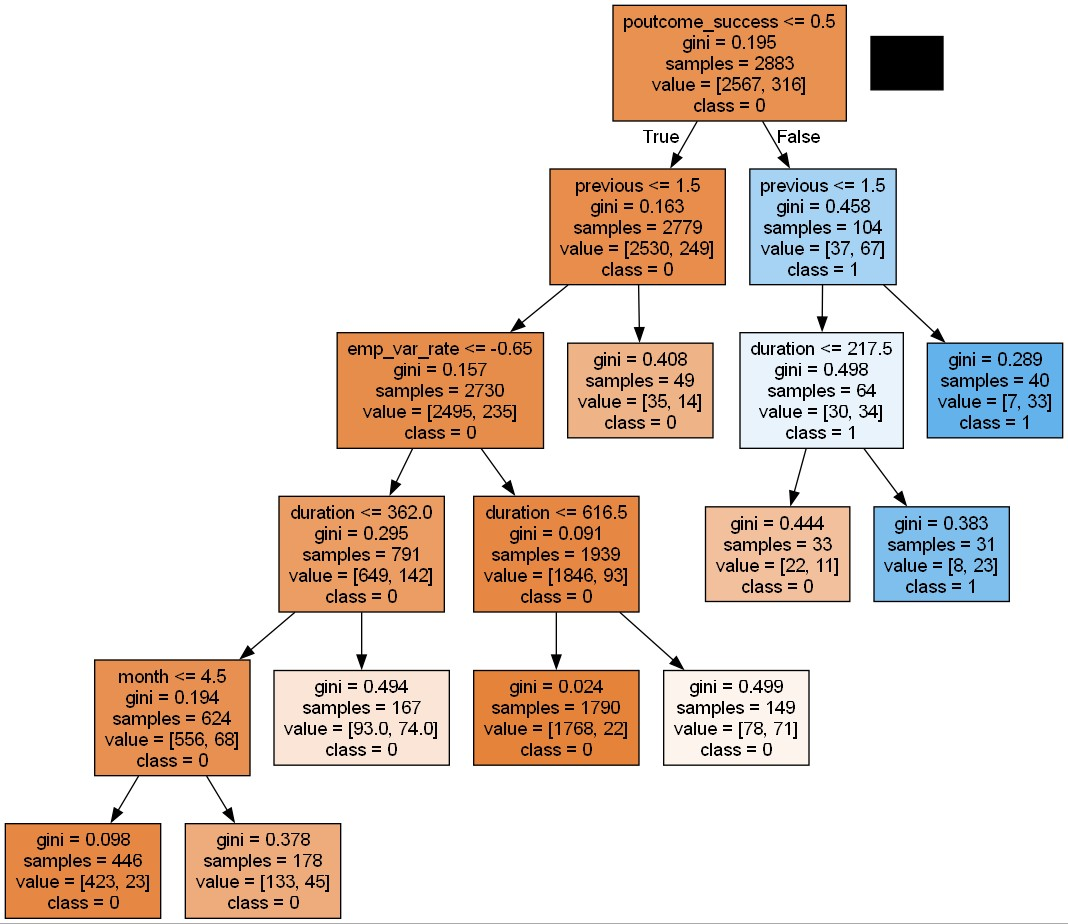

In [79]:
# viewing the image in notebook
from IPython.display import Image
Image(filename='bank_tree.jpg')

### Random Forest

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
gscv_rf = GridSearchCV(estimator = RandomForestClassifier(random_state = 42 ), param_grid={'n_estimators':  [50,60,70,80,90,100],
                                                                           'max_depth': np.arange(4,10),
                                                                           'max_features': np.arange(4,12) },
                                                                 scoring = 'accuracy',  cv = 5, n_jobs = -1,verbose = True )
gscv_rf.fit(x_train, y_train)
print('best_parameters for estimator:',gscv_rf.best_params_)
print('best accuracy score :',gscv_rf.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
best_parameters for estimator: {'max_depth': 8, 'max_features': 10, 'n_estimators': 100}
best accuracy score : 0.9174477662237628


In [82]:
rf_model = RandomForestClassifier(n_estimators = 70, max_depth = 4 , max_features =10, oob_score=True )
rf_model.fit(x_train,y_train) 
rf_model

RandomForestClassifier(max_depth=4, max_features=10, n_estimators=70,
                       oob_score=True)

In [83]:
y_train_pred_prob_rf = pd.DataFrame(rf_model.predict_proba(x_train), index = x_train.index)[1]
y_train_pred_rf = np.where(y_train_pred_prob_rf>= y_train.mean(),1,0)

y_test_pred_prob_rf = pd.DataFrame(rf_model.predict_proba(x_test), index = x_test.index)[1]
y_test_pred_rf = np.where(y_test_pred_prob_rf>= y_train.mean(),1,0)

In [84]:
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_pred_prob_rf))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_pred_prob_rf),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train, y_train_pred_prob_rf) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test, y_test_pred_prob_rf) -1)

ROC AUC (Train): 0.9451250782817948
ROC AUC (Test): 0.9194166918962559 

Somers'D (Train): 0.8902501565635896
Somers'D (Test): 0.8388333837925117


In [85]:
print('predictions for train data using Random Forest: \n',classification_report(y_train, y_train_pred_rf))
print('predictions for test data using Random Forest: \n',classification_report(y_test, y_test_pred_rf))

predictions for train data using Random Forest: 
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      2567
           1       0.44      0.91      0.59       316

    accuracy                           0.86      2883
   macro avg       0.71      0.88      0.76      2883
weighted avg       0.93      0.86      0.88      2883

predictions for test data using Random Forest: 
               precision    recall  f1-score   support

           0       0.98      0.86      0.91      1101
           1       0.42      0.84      0.56       135

    accuracy                           0.86      1236
   macro avg       0.70      0.85      0.74      1236
weighted avg       0.92      0.86      0.88      1236



In [86]:
ft_imp_rf = pd.DataFrame(rf_model.feature_importances_, index = x_train.columns, columns = ['importance' ]).sort_values( by = ['importance'], ascending = False)
ft_imp_rf.T

,duration,poutcome_success,emp_var_rate,month,campaign,previous,day_of_week_mon,day_of_week_thu,job_student,contact_telephone,job_technician,marital_single,job_retired,marital_married,job_blue_collar,housing
importance,0.508324,0.219267,0.133131,0.062647,0.026367,0.019158,0.004336,0.003995,0.003835,0.003484,0.003285,0.003272,0.003224,0.002601,0.002063,0.001011


### XGBoost 

In [87]:
from xgboost import XGBClassifier

In [88]:
gscv_xgb = GridSearchCV(estimator = XGBClassifier(random_state = 42), param_grid={'n_estimators':  [100,200,300,500],
                                                                 'learning_rate': [0.01, 0.05, 0.1],
                                                                 'max_depth': np.arange(3,10),
                                                                 'subsample': [0.5, 0.7, 1.0]},
                                                                 scoring = 'roc_auc',  cv = 5, n_jobs = -1,verbose = True )
gscv_xgb.fit(x_train, y_train)
gscv_xgb

Fitting 5 folds for each of 252 candidates, totalling 1260 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                         'n_estimators': [100, 200, 300, 500],
                         'subsample': [0.5, 0.7, 1.0]},
             scoring='roc_auc', verbose=True)

In [89]:
print('best_parameters for estimator:',gscv_xgb.best_params_)
print('best accuracy score :',gscv_xgb.best_score_)

best_parameters for estimator: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.5}
best accuracy score : 0.9364734188445846


In [90]:
xgb_model = XGBClassifier(n_estimators = 500, max_depth = 3, learning_rate = 0.01, subsample = 0.5).fit(x_train,y_train)
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [91]:
y_train_pred_prob_xgb = pd.DataFrame(xgb_model.predict_proba(x_train), index = x_train.index)[1]
y_train_pred_xgb = np.where(y_train_pred_prob_xgb>= y_train.mean(),1,0)

y_test_pred_prob_xgb = pd.DataFrame(xgb_model.predict_proba(x_test), index = x_test.index)[1]
y_test_pred_xgb = np.where(y_test_pred_prob_xgb>= y_train.mean(),1,0)

In [92]:
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_pred_prob_xgb))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_pred_prob_xgb),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train, y_train_pred_prob_xgb) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test, y_test_pred_prob_xgb) -1)

ROC AUC (Train): 0.9529329168166554
ROC AUC (Test): 0.92899384398022 

Somers'D (Train): 0.9058658336333107
Somers'D (Test): 0.85798768796044


In [93]:
print('predictions for train data using XGBoost: \n',classification_report(y_train, y_train_pred_xgb))
print('predictions for test data using XGBoost: \n',classification_report(y_test, y_test_pred_xgb))

predictions for train data using XGBoost: 
               precision    recall  f1-score   support

           0       0.99      0.84      0.91      2567
           1       0.42      0.93      0.58       316

    accuracy                           0.85      2883
   macro avg       0.71      0.89      0.75      2883
weighted avg       0.93      0.85      0.88      2883

predictions for test data using XGBoost: 
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      1101
           1       0.41      0.87      0.56       135

    accuracy                           0.85      1236
   macro avg       0.70      0.86      0.73      1236
weighted avg       0.92      0.85      0.87      1236



### LightGBM

In [94]:
from lightgbm import LGBMClassifier

In [95]:
gscv_lgbm = GridSearchCV(LGBMClassifier(random_state=42),param_grid={
                                                                     'n_estimators': [50,100,200,500],
                                                                     'learning_rate': [0.01, 0.05],
                                                                     'max_depth': [3,4,5,6],
                                                                     'num_leaves': [9,16,32]},
                                                        scoring = 'roc_auc',cv = 5, n_jobs = -1, verbose = True)
gscv_lgbm.fit(x_train,y_train)
print('best_parameters for estimator:',gscv_lgbm.best_params_)
print('best accuracy score :',gscv_lgbm.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[LightGBM] [Info] Number of positive: 316, number of negative: 2567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 2883, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.109608 -> initscore=-2.094751
[LightGBM] [Info] Start training from score -2.094751
best_parameters for estimator: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 9}
best accuracy score : 0.9351219265678727


In [97]:
lgbm_model = LGBMClassifier(n_estimators =100 , learning_rate = 0.05 , max_depth = 6, num_leaves = 16)
lgbm_model.fit(x_train,y_train)
lgbm_model

[LightGBM] [Info] Number of positive: 316, number of negative: 2567
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 2883, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.109608 -> initscore=-2.094751
[LightGBM] [Info] Start training from score -2.094751
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(learning_rate=0.05, max_depth=6, num_leaves=16)

In [98]:
y_train_pred_prob_lgbm = pd.DataFrame(lgbm_model.predict_proba(x_train), index = x_train.index)[1]
y_train_pred_lgbm = np.where(y_train_pred_prob_lgbm>= y_train.mean(),1,0)

y_test_pred_prob_lgbm = pd.DataFrame(lgbm_model.predict_proba(x_test), index = x_test.index)[1]
y_test_pred_lgbm = np.where(y_test_pred_prob_lgbm>= y_train.mean(),1,0)

In [99]:
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_pred_prob_lgbm))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_pred_prob_lgbm),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train, y_train_pred_prob_lgbm) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test, y_test_pred_prob_lgbm) -1)

ROC AUC (Train): 0.9733188522286272
ROC AUC (Test): 0.9254213341406803 

Somers'D (Train): 0.9466377044572545
Somers'D (Test): 0.8508426682813606


In [100]:
print('predictions for train data using LGBM: \n',classification_report(y_train, y_train_pred_lgbm))
print('predictions for test data using LGBM: \n',classification_report(y_test, y_test_pred_lgbm))

predictions for train data using LGBM: 
               precision    recall  f1-score   support

           0       1.00      0.86      0.92      2567
           1       0.46      0.97      0.62       316

    accuracy                           0.87      2883
   macro avg       0.73      0.91      0.77      2883
weighted avg       0.94      0.87      0.89      2883

predictions for test data using LGBM: 
               precision    recall  f1-score   support

           0       0.98      0.85      0.91      1101
           1       0.41      0.85      0.56       135

    accuracy                           0.85      1236
   macro avg       0.70      0.85      0.73      1236
weighted avg       0.92      0.85      0.87      1236



### SVM

In [101]:
from sklearn.svm import SVC

In [102]:
gscv_svc = GridSearchCV(estimator = SVC(random_state = 42), param_grid={'C' : [1,5,10,50],
                                                                        'kernel': ['linear', 'poly', 'rbf'],
                                                                        'degree': [1,2,3],
                                                                        'gamma': [0.0001,0.0005,0.001,0.005]},
                                                                scoring = 'roc_auc', cv = 5, n_jobs = -1, verbose = True)
gscv_svc.fit(x_train_scaled,y_train)
gscv_svc                

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [1, 5, 10, 50], 'degree': [1, 2, 3],
                         'gamma': [0.0001, 0.0005, 0.001, 0.005],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='roc_auc', verbose=True)

In [103]:
print('best_parameters for estimator:',gscv_svc.best_params_)
print('best accuracy score :',gscv_svc.best_score_)

best_parameters for estimator: {'C': 5, 'degree': 1, 'gamma': 0.001, 'kernel': 'rbf'}
best accuracy score : 0.9230556131947296


In [104]:
svc_model = SVC(C =50, degree= 1, gamma= 0.001, kernel = 'rbf', probability=True).fit(x_train_scaled, y_train)
svc_model

SVC(C=50, degree=1, gamma=0.001, probability=True)

In [105]:
y_train_pred_prob_svc = pd.DataFrame(svc_model.predict_proba(x_train_scaled), index = x_train_scaled.index).loc[:,1]
y_train_pred_svc = np.where(y_train_pred_prob_svc>=y_train.mean(),1,0)

y_test_pred_prob_svc = pd.DataFrame(svc_model.predict_proba(x_test_scaled), index = x_test_scaled.index).loc[:,1]
y_test_pred_svc = np.where(y_test_pred_prob_svc>=y_train.mean(),1,0)

In [106]:
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_pred_prob_svc))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_pred_prob_svc),'\n')

print("Somers'D (Train):", 2*roc_auc_score(y_train, y_train_pred_prob_svc) -1)
print("Somers'D (Test):", 2*roc_auc_score(y_test, y_test_pred_prob_svc) -1)

ROC AUC (Train): 0.9310738043226345
ROC AUC (Test): 0.9154304167928146 

Somers'D (Train): 0.8621476086452691
Somers'D (Test): 0.8308608335856291


In [107]:
print('predictions for train data using SVC: \n',classification_report(y_train, y_train_pred_svc))
print('predictions for test data using SVC: \n',classification_report(y_test, y_test_pred_svc))

predictions for train data using SVC: 
               precision    recall  f1-score   support

           0       0.98      0.86      0.92      2567
           1       0.43      0.84      0.57       316

    accuracy                           0.86      2883
   macro avg       0.71      0.85      0.75      2883
weighted avg       0.92      0.86      0.88      2883

predictions for test data using SVC: 
               precision    recall  f1-score   support

           0       0.96      0.87      0.91      1101
           1       0.41      0.74      0.53       135

    accuracy                           0.85      1236
   macro avg       0.69      0.80      0.72      1236
weighted avg       0.90      0.85      0.87      1236



### Voting Classifier

In [108]:
from sklearn.ensemble import VotingClassifier

In [109]:
vote_model = VotingClassifier(estimators = [('LR',lr_clf_model),('DT',dt_model), ('RF',rf_model), ('XGB',xgb_model), ('SVM',svc_model)], voting= 'soft')
vote_model.fit(x_train,y_train)
vote_model             

VotingClassifier(estimators=[('LR',
                              LogisticRegression(C=0.1, penalty='l1',
                                                 solver='liblinear')),
                             ('DT',
                              DecisionTreeClassifier(max_depth=6,
                                                     max_features=9,
                                                     max_leaf_nodes=9)),
                             ('RF',
                              RandomForestClassifier(max_depth=4,
                                                     max_features=10,
                                                     n_estimators=70,
                                                     oob_score=True)),
                             ('XGB',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            col...
                                            learning_rate=0.01, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('SVM',
                              SVC(C=50, degree=1, gamma=0.001,
                                  probability=True))],
                 voting='soft')

In [110]:
y_train_pred_vote = vote_model.predict(x_train)
y_test_pred_vote = vote_model.predict(x_test)

In [111]:
print('predictions for train data using Voting Classifier: \n',classification_report(y_train, y_train_pred_vote))
print('predictions for test data using Voting Classifier: \n',classification_report(y_test, y_test_pred_vote))

predictions for train data using Voting Classifier: 
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      2567
           1       0.83      0.37      0.52       316

    accuracy                           0.92      2883
   macro avg       0.88      0.68      0.74      2883
weighted avg       0.92      0.92      0.91      2883

predictions for test data using Voting Classifier: 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      1101
           1       0.61      0.27      0.37       135

    accuracy                           0.90      1236
   macro avg       0.76      0.62      0.66      1236
weighted avg       0.88      0.90      0.88      1236



In [112]:
# Best model for bank FD marketing campaign: XGBoost, because it maximizes recall of potential customers, which directly impacts revenue.

### Save the best model

In [113]:
import pickle 

In [121]:
with open('best_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [ ]:
# load the model for future data
# xgb_model = pickle.load(open('best_model.pkl', 'rb'))